# Decision Tree Using Scikit-learn library

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt 
from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, classification_report

In [2]:
import seaborn as sns

In [3]:
from scipy.stats import chi2_contingency, spearmanr

In [4]:
import statsmodels.api as sm

## Load Data

In [5]:
data = pd.read_csv("Employee.csv")
data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


## Basic EDA

### What is the distribution of education qualifications among employees?

In [6]:
education_uniques, education_count = np.unique(data["Education"], return_counts=True)
education_uniques

array(['Bachelors', 'Masters', 'PHD'], dtype=object)

In [7]:
education_count

array([3601,  873,  179], dtype=int64)

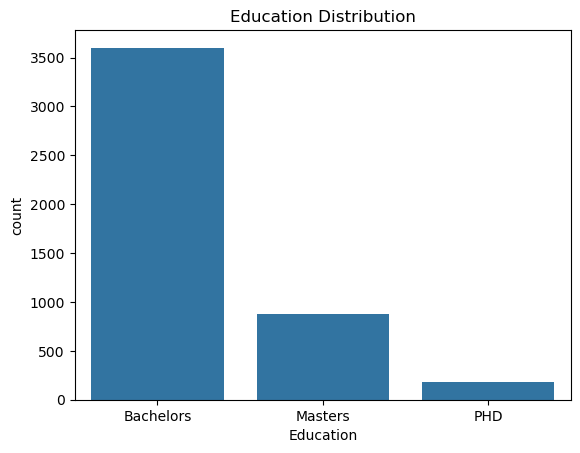

In [8]:
# plot
sns.countplot(data, x="Education")
plt.title("Education Distribution")
plt.show()

There are 3601 employees with Bachelors degree,
873 employees with Master degree,
and 179 employees with PHD

### How does the length of service (Joining Year) vary across different cities?

In [9]:
bangalore_data = data[data["City"] == "Bangalore"]
bangalore_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
10,Masters,2012,Bangalore,3,27,Male,No,5,1
...,...,...,...,...,...,...,...,...,...
4643,Bachelors,2013,Bangalore,3,31,Female,No,5,0
4646,Bachelors,2013,Bangalore,3,25,Female,No,3,0
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


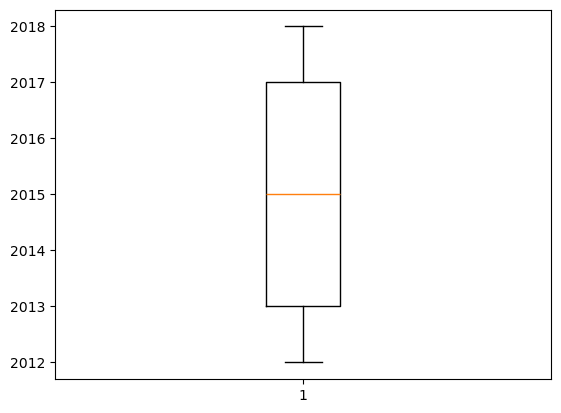

In [10]:
plt.boxplot(bangalore_data["JoiningYear"])
plt.show()

In [11]:
# function to add joining year data of a city to a dict to be used for boxplot
joining_year_dict = {}
def add_joining_year(city_name):
    # check if city exists
    if city_name not in data["City"].values:
        print(f"{city_name} does not exist in this dataset.")
        return
    
    # add joining year for this city
    city_joining_year = data[data["City"] == city_name]["JoiningYear"]
    joining_year_dict[city_name] = city_joining_year

In [12]:
# add joining year of every cities to joining_year_dict
for city_name in data["City"].unique():
    add_joining_year(city_name)

joining_year_dict

{'Bangalore': 0       2017
 3       2016
 5       2016
 7       2016
 10      2012
         ... 
 4643    2013
 4646    2013
 4648    2013
 4651    2012
 4652    2015
 Name: JoiningYear, Length: 2228, dtype: int64,
 'Pune': 1       2013
 4       2017
 8       2016
 11      2016
 12      2018
         ... 
 4630    2012
 4644    2015
 4645    2017
 4647    2016
 4649    2013
 Name: JoiningYear, Length: 1268, dtype: int64,
 'New Delhi': 2       2014
 6       2015
 9       2017
 19      2016
 21      2017
         ... 
 4616    2015
 4618    2017
 4634    2016
 4636    2014
 4650    2018
 Name: JoiningYear, Length: 1157, dtype: int64}

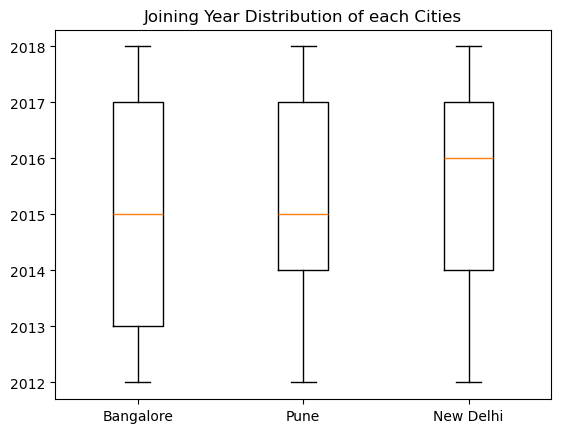

In [13]:
# boxplot joining year of every cities
plt.boxplot(joining_year_dict.values(), labels=joining_year_dict.keys())
plt.title("Joining Year Distribution of each Cities")
plt.show()

50% of employees from Bangalore join from the year 2012-2015.

50% of employees from Pune join from the year 2012-2015.

50% of employees from New Delhi join from the year 2012-2016.

### Is there a correlation between Payment Tier and Experience in Current Domain?

In [14]:
data[["PaymentTier", "ExperienceInCurrentDomain"]]

,PaymentTier,ExperienceInCurrentDomain
0,3,0
1,1,3
2,3,2
3,3,5
4,3,2
...,...,...
4648,3,4
4649,2,2
4650,3,5
4651,3,2


In [15]:
table_count = pd.crosstab(data["ExperienceInCurrentDomain"], data["PaymentTier"])
table_count

PaymentTier,1,2,3
ExperienceInCurrentDomain,,,
0,25,66,264
1,36,90,432
2,51,252,784
3,41,150,595
4,43,184,704
5,45,174,700
6,1,1,6
7,1,1,7


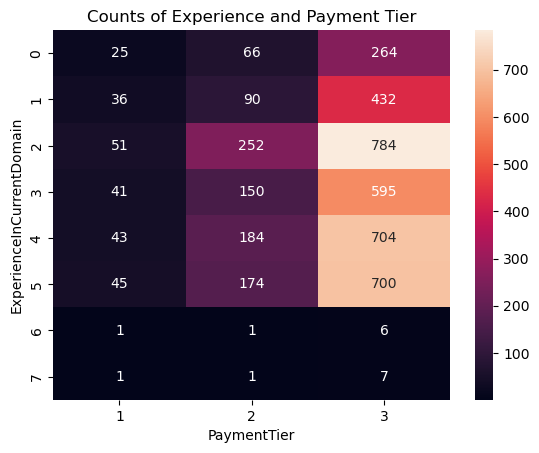

In [16]:
sns.heatmap(table_count, annot=True, fmt='d')
plt.title("Counts of Experience and Payment Tier")
plt.show()

In [17]:
table_prob = pd.crosstab(data["ExperienceInCurrentDomain"], data["PaymentTier"], normalize="index")
table_prob

PaymentTier,1,2,3
ExperienceInCurrentDomain,,,
0,0.070423,0.185915,0.743662
1,0.064516,0.161290,0.774194
2,0.046918,0.231831,0.721251
3,0.052163,0.190840,0.756997
4,0.046187,0.197637,0.756176
5,0.048966,0.189336,0.761697
6,0.125000,0.125000,0.750000
7,0.111111,0.111111,0.777778


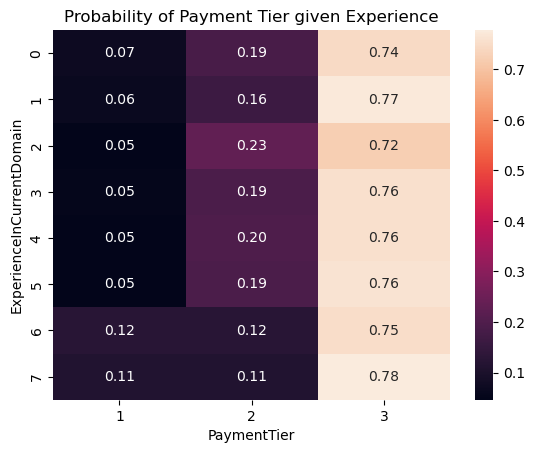

In [18]:
sns.heatmap(table_prob, annot=True, fmt='.2f')
plt.title("Probability of Payment Tier given Experience")
plt.show()

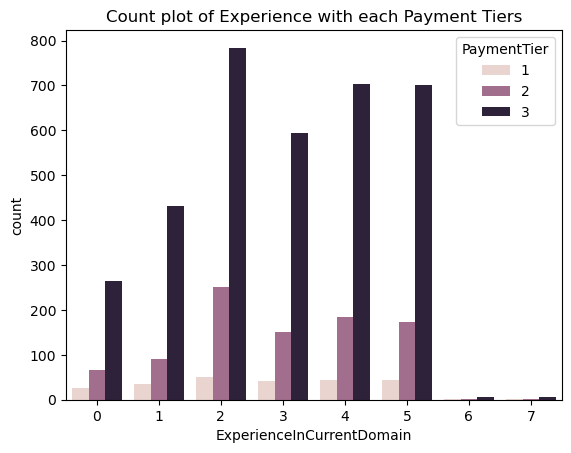

In [19]:
sns.countplot(data, x="ExperienceInCurrentDomain", hue="PaymentTier")
plt.title("Count plot of Experience with each Payment Tiers")
plt.show()

In [20]:
table_count.values

array([[ 25,  66, 264],
       [ 36,  90, 432],
       [ 51, 252, 784],
       [ 41, 150, 595],
       [ 43, 184, 704],
       [ 45, 174, 700],
       [  1,   1,   6],
       [  1,   1,   7]], dtype=int64)

In [21]:
rho, p_value = spearmanr(data["ExperienceInCurrentDomain"], data["PaymentTier"])
p_value

0.3001862448012146

p value > 0.05 which means there is no correlation between Payment Tier and Experience in Current Domain

### What is the gender distribution within the workforce?

In [22]:
gender_uniques, gender_count = np.unique(data["Gender"], return_counts=True)
print(gender_uniques)
print(gender_count)

['Female' 'Male']
[1875 2778]


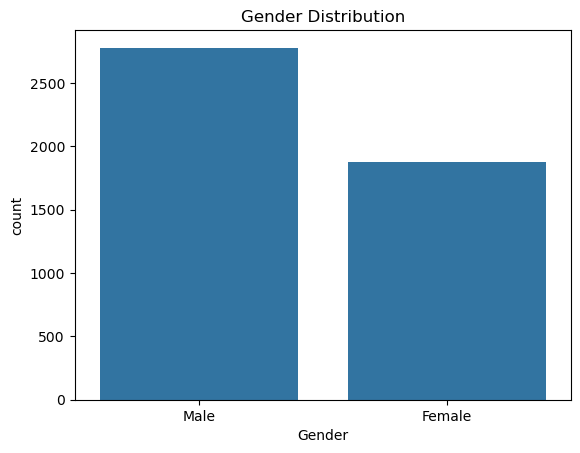

In [23]:
sns.countplot(data, x="Gender")
plt.title("Gender Distribution")
plt.show()

There are more males than females. 1875 females and 2778 males

### Are there any patterns in leave-taking behavior among employees?

Cateorigcal Columns

In [24]:
leave_data = data[data["LeaveOrNot"] == 1]
leave_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
1,Bachelors,2013,Pune,1,28,Female,No,3,1
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
10,Masters,2012,Bangalore,3,27,Male,No,5,1
...,...,...,...,...,...,...,...,...,...
4639,Bachelors,2017,Bangalore,3,28,Male,No,0,1
4641,Bachelors,2016,Bangalore,1,33,Female,No,0,1
4644,Bachelors,2015,Pune,3,32,Female,Yes,1,1
4649,Masters,2013,Pune,2,37,Male,No,2,1


In [25]:
education_leave_table = pd.crosstab(data["Education"], data["LeaveOrNot"], normalize="index")
education_leave_table

LeaveOrNot,0,1
Education,,
Bachelors,0.686476,0.313524
Masters,0.512027,0.487973
PHD,0.748603,0.251397


In [26]:
education_leave_table.index

Index(['Bachelors', 'Masters', 'PHD'], dtype='object', name='Education')

In [27]:
education_leave_table[1]

Education
Bachelors    0.313524
Masters      0.487973
PHD          0.251397
Name: 1, dtype: float64

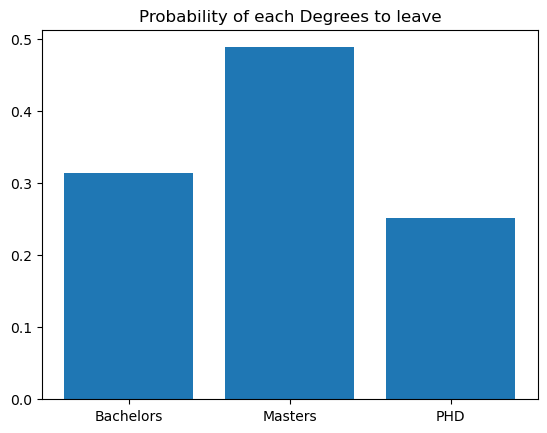

In [28]:
plt.bar(education_leave_table.index, education_leave_table[1])
plt.title("Probability of each Degrees to leave")
plt.show()

In [29]:
# probability to leave for cateorigcal columns
def get_probability_to_leave(column_name):
    # check if column exists
    if column_name not in data.columns or column_name not in leave_data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return
    # get crosstab probability of leave given column values
    column_leave_table = pd.crosstab(data[column_name], data["LeaveOrNot"], normalize="index")

    return column_leave_table

get_probability_to_leave("City")

LeaveOrNot,0,1
City,,
Bangalore,0.732944,0.267056
New Delhi,0.683665,0.316335
Pune,0.496057,0.503943


In [30]:
# get probability to leave for every cateorigcal columns
education_leave_prob = get_probability_to_leave("Education")
city_leave_prob = get_probability_to_leave("City")
payment_leave_prob = get_probability_to_leave("PaymentTier")
gender_leave_prob = get_probability_to_leave("Gender")
benched_leave_prob = get_probability_to_leave("EverBenched")

In [31]:
payment_leave_prob.index = payment_leave_prob.index.astype(str)
payment_leave_prob.index

Index(['1', '2', '3'], dtype='object', name='PaymentTier')

In [32]:
payment_leave_prob

LeaveOrNot,0,1
PaymentTier,,
1,0.633745,0.366255
2,0.400871,0.599129
3,0.724800,0.275200


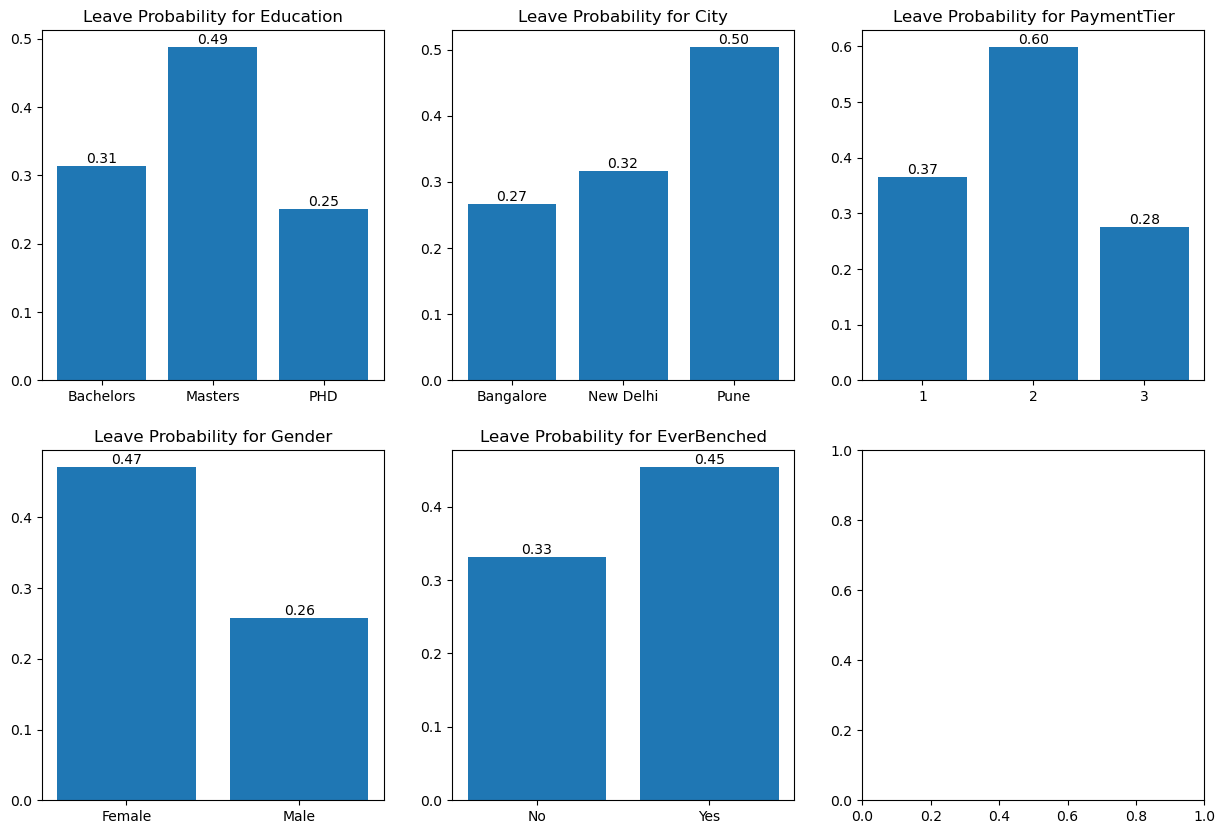

In [33]:
# bar plot of probability to leave for every cateorigcal columns
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
def plot_prob(x_index, y_index, prob_data):
    axs[x_index, y_index].set_title(f"Leave Probability for {prob_data.index.name}")
    bar = axs[x_index, y_index].bar(prob_data.index, prob_data[1])
    axs[x_index, y_index].bar_label(bar, fmt="%.2f")

plot_prob(0, 0, education_leave_prob)
plot_prob(0, 1, city_leave_prob)
plot_prob(0, 2, payment_leave_prob)
plot_prob(1, 0, gender_leave_prob)
plot_prob(1, 1, benched_leave_prob)

plt.show()

Numerical Columns

In [34]:
no_leave_data = data[data["LeaveOrNot"] == 0]
no_leave_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
8,Bachelors,2016,Pune,3,23,Male,No,1,0
...,...,...,...,...,...,...,...,...,...
4646,Bachelors,2013,Bangalore,3,25,Female,No,3,0
4647,Bachelors,2016,Pune,3,30,Male,No,2,0
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


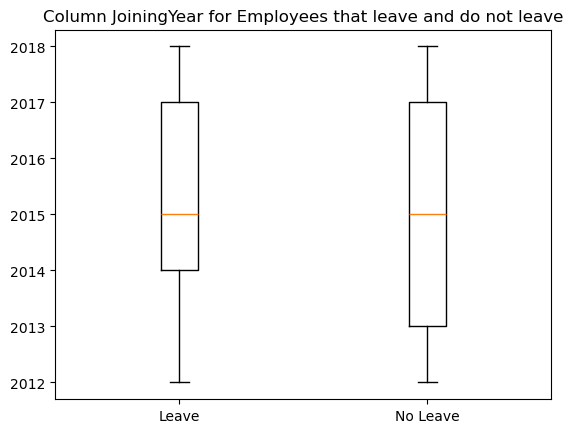

In [35]:
# box plot comparing leave and no leave data for each numerical columns
def box_compare(column_name):
     # check if column exists
    if column_name not in no_leave_data.columns or column_name not in leave_data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return

    plt.boxplot([leave_data[column_name], no_leave_data[column_name]], labels=["Leave", "No Leave"])
    plt.title(f"Column {column_name} for Employees that leave and do not leave")
    plt.show()

box_compare("JoiningYear")

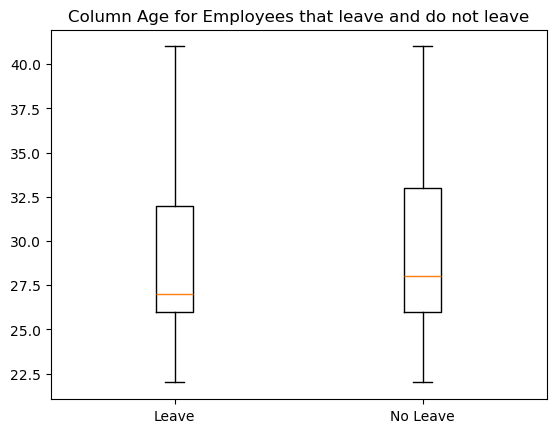

In [36]:
box_compare("Age")

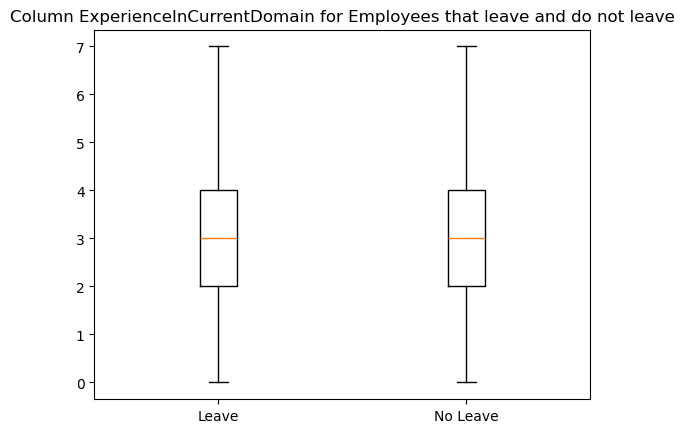

In [37]:
box_compare("ExperienceInCurrentDomain")

In [38]:
def plot_prob_to_leave(column_name, plot_type="line"):
    # check if column exists
    if column_name not in no_leave_data.columns or column_name not in leave_data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return

    column_leave_table = pd.crosstab(data[column_name], data["LeaveOrNot"], normalize="index")
    if plot_type == "scatter":
        plt.scatter(column_leave_table.index, column_leave_table[1])
    else:
        column_leave_table[1].plot()
    plt.title("Probability to leave given " + column_name)
    plt.show()

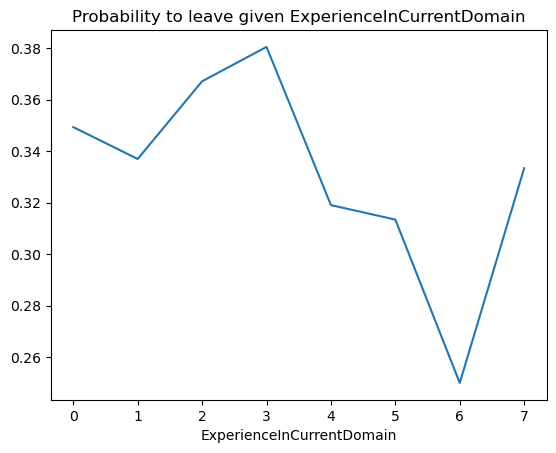

In [39]:
plot_prob_to_leave("ExperienceInCurrentDomain")

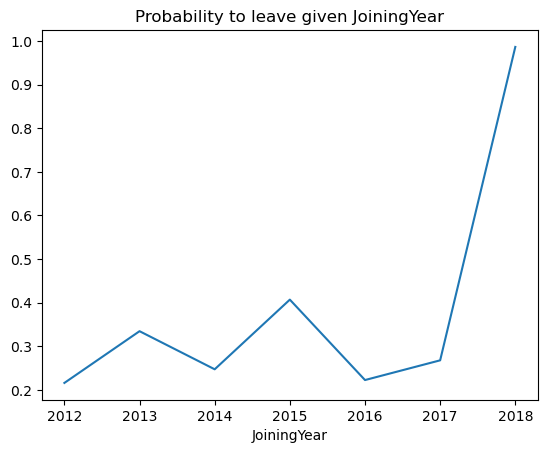

In [40]:
plot_prob_to_leave("JoiningYear")

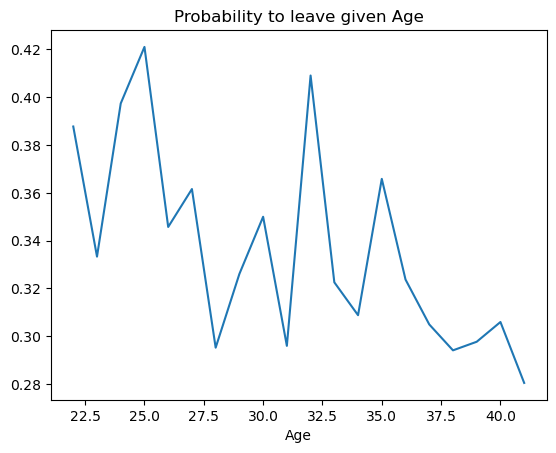

In [41]:
plot_prob_to_leave("Age")

Correlation Test

In [42]:
education_leave_count = pd.crosstab(data["Education"], data["LeaveOrNot"])
education_leave_count

LeaveOrNot,0,1
Education,,
Bachelors,2472,1129
Masters,447,426
PHD,134,45


In [43]:
# chi square test for categorical columns
def chi_square_test(column_name):
     # check if column exists
    if column_name not in data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return

    alpha = 0.05
    # create count table for this column and LeaveOrNot
    column_leave_count = pd.crosstab(data[column_name], data["LeaveOrNot"])
    # chi square to test correlation between the column and LeaveOrNot
    statistic, p_value, dof, expected_freq = chi2_contingency(column_leave_count)
    # correlation test summary
    print("p-value is " + str(p_value))
    if p_value < alpha:
        print(column_name + " is correlated to leaving")
    else:
        print(column_name + " is NOT correlated to leaving")

In [44]:
chi_square_test("Education")

p-value is 7.724417739147332e-23
Education is correlated to leaving


In [45]:
chi_square_test("City")

p-value is 1.7106992135618012e-45
City is correlated to leaving


In [46]:
chi_square_test("PaymentTier")

p-value is 2.9329904732261673e-74
PaymentTier is correlated to leaving


In [47]:
chi_square_test("Gender")

p-value is 5.177873883438753e-51
Gender is correlated to leaving


In [48]:
chi_square_test("EverBenched")

p-value is 1.1603340647939294e-07
EverBenched is correlated to leaving


In [49]:
# logistic regression for numerical columns
def logistic_test(column_name):
    # check if column exists
    if column_name not in data.columns:
        print(f"Column {column_name} does not exist on the dataset.")
        return

    # create logistic regression model
    X = data[[column_name]]
    y = data["LeaveOrNot"]

    X = sm.add_constant(X)

    model = sm.Logit(y, X).fit()

    # correlation test summary
    print(model.summary())

    alpha = 0.05
    p_value = model.pvalues[column_name]
    coef = model.params[column_name]
    print("p-value is " + str(p_value))
    print("coef is " + str(coef))
    if p_value < alpha and coef != 0:
        print(f"{column_name} is correlated to leaving")
        if coef < 0:
            print(f"The probability of leaving decrease as {column_name} increase")
        else:
            print(f"The probability of leaving increase as {column_name} increase")
    else:
        print(f"{column_name} is NOT correlated to leaving")

In [50]:
logistic_test("ExperienceInCurrentDomain")

Optimization terminated successfully.
         Current function value: 0.643100
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             LeaveOrNot   No. Observations:                 4653
Model:                          Logit   Df Residuals:                     4651
Method:                           MLE   Df Model:                            1
Date:                Wed, 06 May 2026   Pseudo R-squ.:               0.0007224
Time:                        17:36:16   Log-Likelihood:                -2992.3
converged:                       True   LL-Null:                       -2994.5
Covariance Type:            nonrobust   LLR p-value:                   0.03752
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -0.5271      0.065     -8.141      0.000      -0.

In [51]:
logistic_test("JoiningYear")

Optimization terminated successfully.
         Current function value: 0.626787
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             LeaveOrNot   No. Observations:                 4653
Model:                          Logit   Df Residuals:                     4651
Method:                           MLE   Df Model:                            1
Date:                Wed, 06 May 2026   Pseudo R-squ.:                 0.02607
Time:                        17:36:16   Log-Likelihood:                -2916.4
converged:                       True   LL-Null:                       -2994.5
Covariance Type:            nonrobust   LLR p-value:                 7.897e-36
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -427.1452     34.820    -12.267      0.000    -495.392    -358.898
JoiningYear     0.2116    

In [52]:
logistic_test("Age")

Optimization terminated successfully.
         Current function value: 0.642243
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             LeaveOrNot   No. Observations:                 4653
Model:                          Logit   Df Residuals:                     4651
Method:                           MLE   Df Model:                            1
Date:                Wed, 06 May 2026   Pseudo R-squ.:                0.002054
Time:                        17:36:16   Log-Likelihood:                -2988.4
converged:                       True   LL-Null:                       -2994.5
Covariance Type:            nonrobust   LLR p-value:                 0.0004521
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0195      0.193      0.101      0.920      -0.359       0.398
Age           -0.0227      0.

**Summary:** Every columns are correlated to leaving, and the most likely to leave for each features are

Education: Master

City: Pune

PaymentTier: 2

Gender: Female

EverBenched: Yes


The less Experience the more likely to leave

The later JoiningYear the more likely to leave

The younger the more likely to leave

## Machine Learning Model

### Convert Data to Number

In [53]:
converted_data = data
converted_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [54]:
# Use Label Encoder for ordinal feature
label_encoder = LabelEncoder()
converted_data["Education"] = label_encoder.fit_transform(converted_data["Education"])
converted_data

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,0,2017,Bangalore,3,34,Male,No,0,0
1,0,2013,Pune,1,28,Female,No,3,1
2,0,2014,New Delhi,3,38,Female,No,2,0
3,1,2016,Bangalore,3,27,Male,No,5,1
4,1,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,0,2013,Bangalore,3,26,Female,No,4,0
4649,1,2013,Pune,2,37,Male,No,2,1
4650,1,2018,New Delhi,3,27,Male,No,5,1
4651,0,2012,Bangalore,3,30,Male,Yes,2,0


In [55]:
# One-Hot Encoding for categorical features
converted_data = pd.get_dummies(converted_data)
converted_data

,Education,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes
0,0,2017,3,34,0,0,True,False,False,False,True,True,False
1,0,2013,1,28,3,1,False,False,True,True,False,True,False
2,0,2014,3,38,2,0,False,True,False,True,False,True,False
3,1,2016,3,27,5,1,True,False,False,False,True,True,False
4,1,2017,3,24,2,1,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4648,0,2013,3,26,4,0,True,False,False,True,False,True,False
4649,1,2013,2,37,2,1,False,False,True,False,True,True,False
4650,1,2018,3,27,5,1,False,True,False,False,True,True,False
4651,0,2012,3,30,2,0,True,False,False,False,True,False,True


### Train Test Split

In [56]:
X = converted_data.drop(columns=["LeaveOrNot"])
X

,Education,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,City_Bangalore,City_New Delhi,City_Pune,Gender_Female,Gender_Male,EverBenched_No,EverBenched_Yes
0,0,2017,3,34,0,True,False,False,False,True,True,False
1,0,2013,1,28,3,False,False,True,True,False,True,False
2,0,2014,3,38,2,False,True,False,True,False,True,False
3,1,2016,3,27,5,True,False,False,False,True,True,False
4,1,2017,3,24,2,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
4648,0,2013,3,26,4,True,False,False,True,False,True,False
4649,1,2013,2,37,2,False,False,True,False,True,True,False
4650,1,2018,3,27,5,False,True,False,False,True,True,False
4651,0,2012,3,30,2,True,False,False,False,True,False,True


In [57]:
y = converted_data["LeaveOrNot"]
y

0       0
1       1
2       0
3       1
4       1
       ..
4648    0
4649    1
4650    1
4651    0
4652    0
Name: LeaveOrNot, Length: 4653, dtype: int64

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [59]:
print("Training Size =", X_train.shape[0])
print("Test Size =", X_test.shape[0])

Training Size = 3722
Test Size = 931


make sure that both y_train and y_test have the same label proportion as the whole data

In [60]:
y_train_unique_values, y_train_unique_count = np.unique(y_train, return_counts=True)
print("y_train unique values and count")
print(y_train_unique_values)
print(y_train_unique_count)

y_train unique values and count
[0 1]
[2442 1280]


In [61]:
y_test_unique_values, y_test_unique_count = np.unique(y_test, return_counts=True)
print("y_test unique values and count")
print(y_test_unique_values)
print(y_test_unique_count)

y_test unique values and count
[0 1]
[611 320]


### Model Training

In [62]:
np.arange(2, 102, 4)

array([ 2,  6, 10, 14, 18, 22, 26, 30, 34, 38, 42, 46, 50, 54, 58, 62, 66,
       70, 74, 78, 82, 86, 90, 94, 98])

In [63]:
# decision tree parameters for grid search cv
params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": np.arange(1, 21),
    "min_samples_split": np.arange(2, 102, 4)
}

In [64]:
model = tree.DecisionTreeClassifier()
grid_search_cv = GridSearchCV(estimator=model, param_grid=params)
grid_search_cv.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20]),
                         'min_samples_split': array([ 2,  6, 10, 14, 18, 22, 26, 30, 34, 38, 42, 46, 50, 54, 58, 62, 66,
       70, 74, 78, 82, 86, 90, 94, 98])})

In [65]:
print("Best parameters =", grid_search_cv.best_params_)
print("Best score =", grid_search_cv.best_score_)

Best parameters = {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 34}
Best score = 0.8543808183589523


In [66]:
best_model = grid_search_cv.best_estimator_

In [67]:
print("Depth =", best_model.get_depth())
print("Number of leaves =", best_model.get_n_leaves())

Depth = 6
Number of leaves = 33


### Model Evaluation

In [68]:
y_pred = best_model.predict(X_test)
y_pred

array([0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [69]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
cm

array([[563,  48],
       [ 98, 222]], dtype=int64)

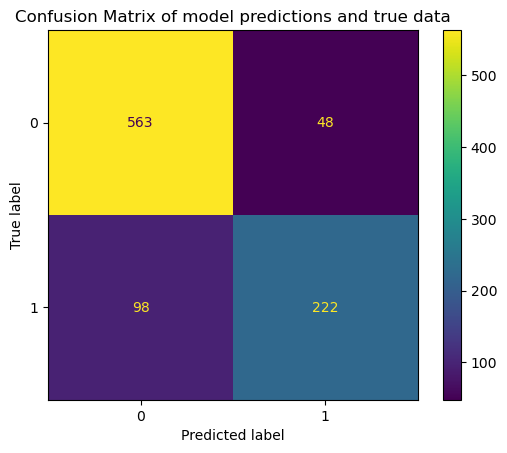

In [70]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
cm_display.plot()
plt.title("Confusion Matrix of model predictions and true data")
plt.show()

In [71]:
print("Accuracy =", accuracy_score(y_test, y_pred))
print("Precision =", precision_score(y_test, y_pred))
print("Recall =", recall_score(y_test, y_pred))

Accuracy = 0.8431793770139635
Precision = 0.8222222222222222
Recall = 0.69375


In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89       611
           1       0.82      0.69      0.75       320

    accuracy                           0.84       931
   macro avg       0.84      0.81      0.82       931
weighted avg       0.84      0.84      0.84       931



In [76]:
X_test.columns

Index(['Education', 'JoiningYear', 'PaymentTier', 'Age',
       'ExperienceInCurrentDomain', 'City_Bangalore', 'City_New Delhi',
       'City_Pune', 'Gender_Female', 'Gender_Male', 'EverBenched_No',
       'EverBenched_Yes'],
      dtype='object')

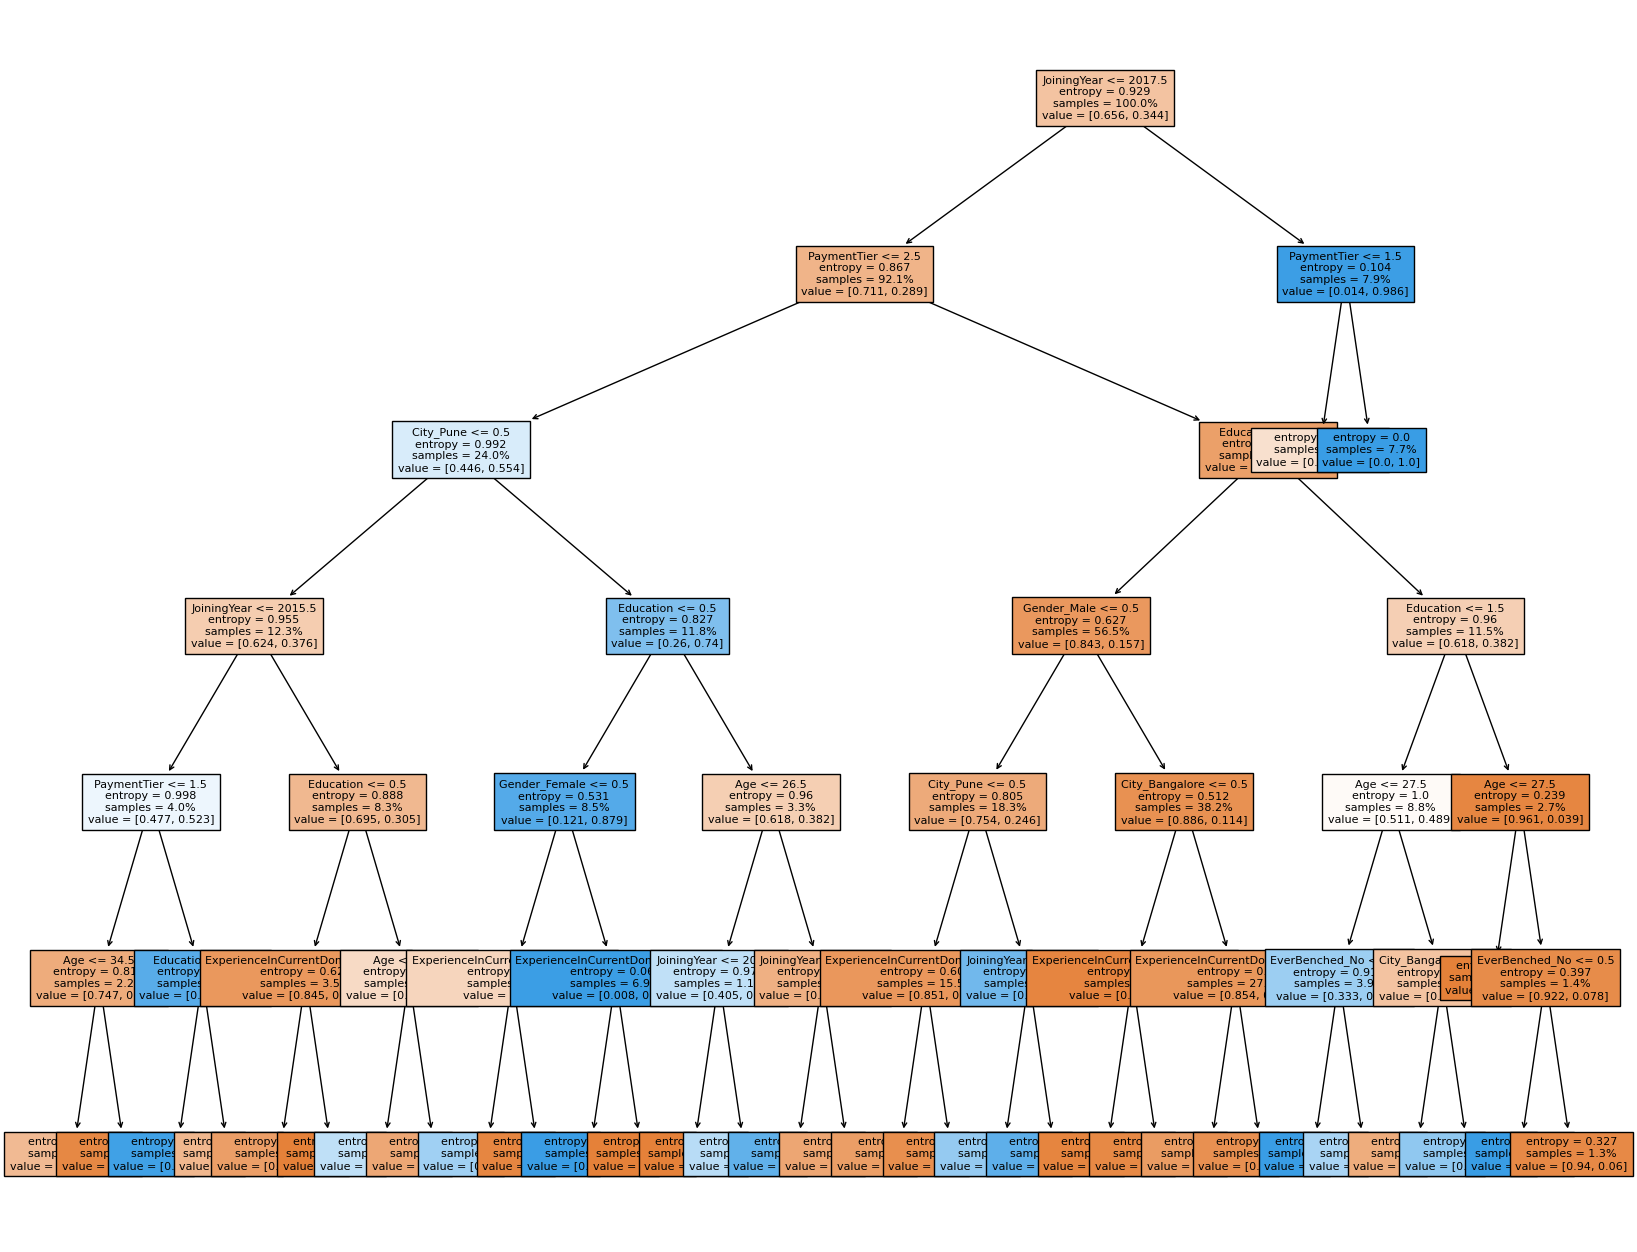

In [88]:
plt.figure(figsize=(20, 16))
tree.plot_tree(best_model, feature_names=X_test.columns, filled=True, proportion=True, fontsize=8)
plt.show()